#1.Title + Objective

#Stadium Advantage Analysis in IPL

This analysis explores whether certain IPL venues favor teams batting first or second.
By comparing two eras:
- Early IPL (before 2015)
- Modern IPL (2015 onwards)

###Objective
- Identify top 10 venues by match count
- Compare defending vs chasing win ratios
- Analyze how this trend changes across eras

#2. Import Libraries

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#3.Load Dataset

In [48]:
df = pd.read_csv('matches.csv')
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


#4.Data Cleaning

In [49]:
# Remove matches with no result
df = df[df['result'] != 'no result']

# Remove matches with no winner
df = df[df['winner'].notna()]


Removed no-result matches to ensure accurate analysis.

#5.Feature Selection



In [50]:
df = df[['team1', 'team2', 'winner', 'venue', 'season', 'result']]
df.head()

,team1,team2,winner,venue,season,result
0,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium,2007/08,runs
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",2007/08,runs
2,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,Feroz Shah Kotla,2007/08,wickets
3,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,Wankhede Stadium,2007/08,wickets
4,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders,Eden Gardens,2007/08,wickets


Selected only relevant columns required for analysis to improve clarity and efficiency.

##6.Top Venues Distribution


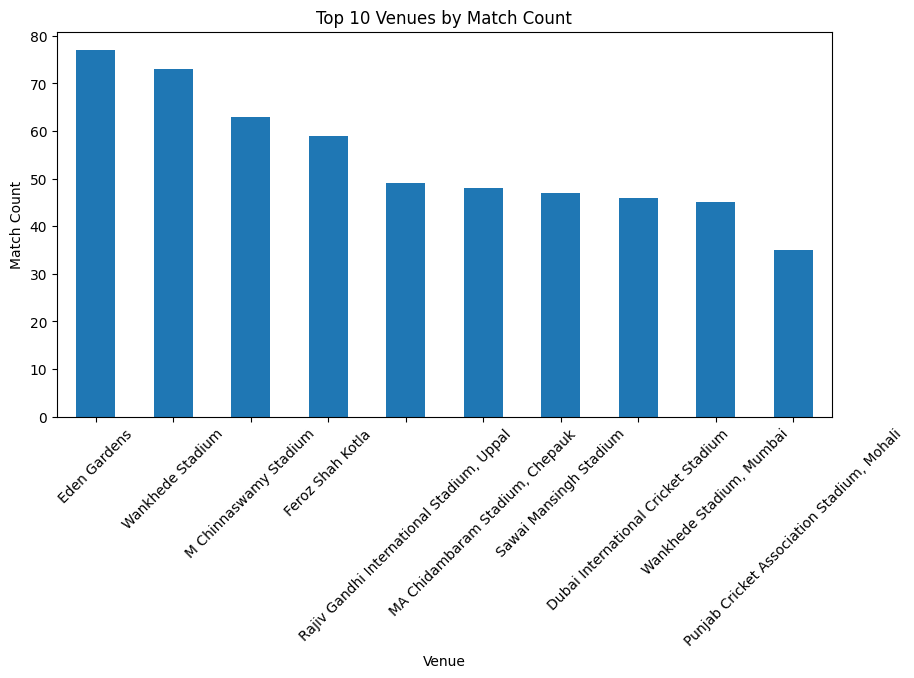

In [51]:
df['venue'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Venues by Match Count")
plt.xlabel("Venue")
plt.ylabel("Match Count")
plt.xticks(rotation=45)
plt.show()

##Graph Explanation

This bar chart shows the top 10 IPL venues based on the number of matches hosted.

- The x-axis represents different stadiums.
- The y-axis represents the total number of matches played at each venue.

This helps identify the most frequently used venues, which are selected for further analysis to ensure sufficient data for reliable insights.

#7.Create Result Type


In [52]:
def get_result_type(row):
    if row['winner'] == row['team1']:
        return 'defend'
    else:
        return 'chase'

df['result_type'] = df.apply(get_result_type, axis=1)

classified each match based on how the winning team played:

- If the team batting first (team1) wins -> it is a **defend**
- If the team batting second (team2) wins -> it is a **chase**

This helps understand whether defending or chasing is more successful.

#8.Select Top Venues

In [53]:
top_venues = df['venue'].value_counts().head(10).index
df_top = df[df['venue'].isin(top_venues)]

Selected top 10 statiums based on the number of matches played

##9.Season Cleaning

The season column contains values like "2007/08".

Extracted only the starting year (e.g., 2007) and convert it into numeric format for analysis.

In [54]:
df['season'] = df['season'].astype(str).str[:4]
df['season'] = df['season'].astype(int)

##10.Create Era
Divide matches into two time periods:

- Early IPL -> seasons before 2015  
- Modern IPL -> seasons from 2015 onwards  

This helps compare how trends have changed over time.

In [55]:
df['era'] = df['season'].apply(lambda x: 'Early IPL' if x < 2015 else 'Modern IPL')

##11.Grouping Data

Grouped the data by:
- Venue  
- Era  
- Result type (defend or chase)  



In [56]:
top_venues = df['venue'].value_counts().head(10).index
df_top = df[df['venue'].isin(top_venues)]

result = df_top.groupby(['venue', 'era', 'result_type']).size().reset_index(name='count')

##12.Data Transformation (Pivot Table)
Reshape the data so that:

- Each row represents a venue and era  
- Columns show number of matches won by:
  - Defending teams  
  - Chasing teams  

This makes comparison easier.

In [59]:
result = df_top.groupby(['venue', 'era', 'result_type']).size().reset_index(name='count')

pivot = result.pivot_table(index=['venue', 'era'],
                           columns='result_type',
                           values='count',
                           fill_value=0)

pivot['total'] = pivot['defend'] + pivot['chase']
pivot['defend_ratio'] = pivot['defend'] / pivot['total']
pivot['chase_ratio'] = pivot['chase'] / pivot['total']

pivot = pivot.reset_index()

#13.Visualisation

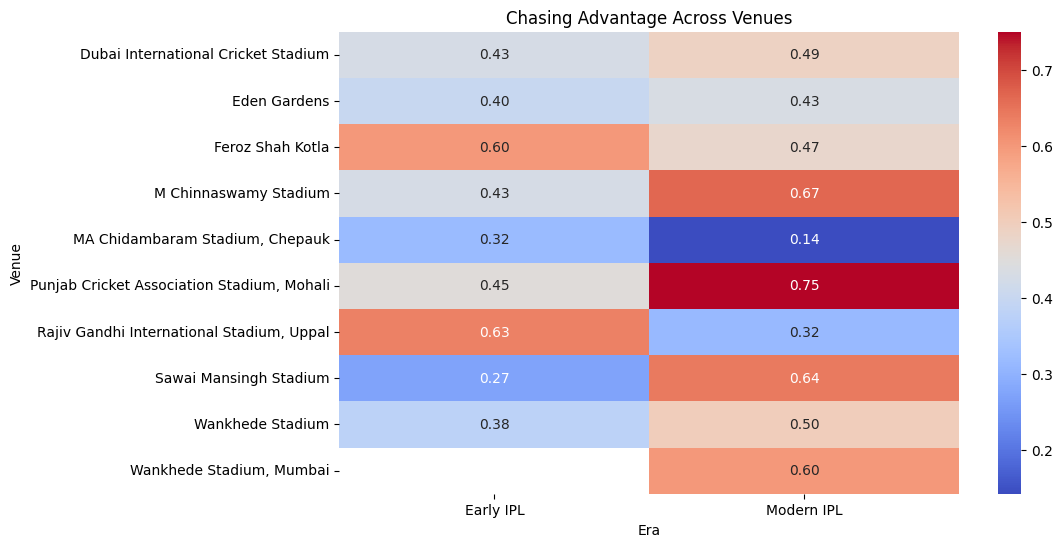

In [58]:
import seaborn as sns

heatmap_data = pivot.pivot(index='venue', columns='era', values='chase_ratio')

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Chasing Advantage Across Venues')
plt.xlabel('Era')
plt.ylabel('Venue')

plt.show()

##Chasing Advantage Heatmap

This heatmap shows the chasing win ratio across venues and eras.

- Higher values-> stronger chasing advantage  
- Lower values-> stronger defending advantage  

This visualization helps compare trends across stadiums and time periods.

#14.Insights

- Some stadiums clearly favor chasing, especially in the modern IPL.
- Chasing advantage has increased in many venues in recent years.

###Key Observations

- Punjab Cricket Association Stadium, Mohali shows a very strong chasing advantage in Modern IPL (~0.75).
- M Chinnaswamy Stadium and Sawai Mansingh Stadium also favor chasing in modern IPL.
- MA Chidambaram Stadium (Chepauk) strongly favors defending, especially in modern IPL (~0.14 chasing ratio).

-Best stadium to chase: Punjab Cricket Association Stadium, Mohali  
-Best stadium to defend: MA Chidambaram Stadium, Chepauk